In [156]:
import pandas as pd 
import os
import re
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('../../')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import numpy as np
from numpy import sign

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("Set2")

file_path = '../freqtrade-grid/user_data/data/binance/futures'
time_frame = '1d'

def extract_coin_symbols(directory):
    coin_list = []
    pattern = re.compile(r'(.+?)_USDT-1d-futures\.feather$')

    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            coin_symbol = (match.group(1)+':USDT').replace('_','/')
            coin_list.append(coin_symbol)
    
    return coin_list


if os.path.exists(file_path) and os.path.isdir(file_path):
    coins = extract_coin_symbols(file_path)
# print(coins)
top50 = [
"BTC/USDT:USDT","ETH/USDT:USDT","XRP/USDT:USDT","BNB/USDT:USDT","SOL/USDT:USDT","DOGE/USDT:USDT","TRX/USDT:USDT","ADA/USDT:USDT","SUI/USDT:USDT","HYPE/USDT:USDT","LINK/USDT:USDT","AVAX/USDT:USDT","XLM/USDT:USDT","TON/USDT:USDT","BCH/USDT:USDT","HBAR/USDT:USDT","LTC/USDT:USDT","DOT/USDT:USDT","XMR/USDT:USDT","UNI/USDT:USDT","AAVE/USDT:USDT","TAO/USDT:USDT","NEAR/USDT:USDT","APT/USDT:USDT","ONDO/USDT:USDT","ICP/USDT:USDT","ETC/USDT:USDT","KAS/USDT:USDT","POL/USDT:USDT","TRUMP/USDT:USDT","VET/USDT:USDT","RENDER/USDT:USDT","ENA/USDT:USDT","FET/USDT:USDT","WLD/USDT:USDT","ARB/USDT:USDT","FIL/USDT:USDT"
]

top100 = [
"BTC/USDT:USDT","ETH/USDT:USDT","XRP/USDT:USDT","BNB/USDT:USDT","SOL/USDT:USDT","DOGE/USDT:USDT","TRX/USDT:USDT","ADA/USDT:USDT","SUI/USDT:USDT","HYPE/USDT:USDT","LINK/USDT:USDT","AVAX/USDT:USDT","XLM/USDT:USDT","TON/USDT:USDT","BCH/USDT:USDT","HBAR/USDT:USDT","LTC/USDT:USDT","DOT/USDT:USDT","XMR/USDT:USDT","UNI/USDT:USDT","AAVE/USDT:USDT","TAO/USDT:USDT","NEAR/USDT:USDT","APT/USDT:USDT","ONDO/USDT:USDT","ICP/USDT:USDT","ETC/USDT:USDT","KAS/USDT:USDT","POL/USDT:USDT","TRUMP/USDT:USDT","VET/USDT:USDT","RENDER/USDT:USDT","ENA/USDT:USDT","FET/USDT:USDT","WLD/USDT:USDT","ARB/USDT:USDT","FIL/USDT:USDT","ATOM/USDT:USDT","ALGO/USDT:USDT","JUP/USDT:USDT","TIA/USDT:USDT","VIRTUAL/USDT:USDT","INJ/USDT:USDT","QNT/USDT:USDT","STX/USDT:USDT","S/USDT:USDT","DEXE/USDT:USDT","OP/USDT:USDT","FARTCOIN/USDT:USDT","IP/USDT:USDT","FORM/USDT:USDT","SEI/USDT:USDT","A/USDT:USDT","SPX/USDT:USDT","IMX/USDT:USDT","WIF/USDT:USDT","GRT/USDT:USDT","CRV/USDT:USDT","LDO/USDT:USDT","ZEC/USDT:USDT","ENS/USDT:USDT","JASMY/USDT:USDT","THETA/USDT:USDT","CAKE/USDT:USDT","GALA/USDT:USDT","WAL/USDT:USDT","SAND/USDT:USDT","IOTA/USDT:USDT","PYTH/USDT:USDT","PENGU/USDT:USDT","BSV/USDT:USDT","PENDLE/USDT:USDT","KAIA/USDT:USDT"
]

top150 = [
"BTC/USDT:USDT","ETH/USDT:USDT","XRP/USDT:USDT","BNB/USDT:USDT","SOL/USDT:USDT","DOGE/USDT:USDT","TRX/USDT:USDT","ADA/USDT:USDT","SUI/USDT:USDT","HYPE/USDT:USDT","LINK/USDT:USDT","AVAX/USDT:USDT","XLM/USDT:USDT","TON/USDT:USDT","BCH/USDT:USDT","HBAR/USDT:USDT","LTC/USDT:USDT","DOT/USDT:USDT","XMR/USDT:USDT","UNI/USDT:USDT","AAVE/USDT:USDT","TAO/USDT:USDT","NEAR/USDT:USDT","APT/USDT:USDT","ONDO/USDT:USDT","ICP/USDT:USDT","ETC/USDT:USDT","KAS/USDT:USDT","POL/USDT:USDT","TRUMP/USDT:USDT","VET/USDT:USDT","RENDER/USDT:USDT","ENA/USDT:USDT","FET/USDT:USDT","WLD/USDT:USDT","ARB/USDT:USDT","FIL/USDT:USDT","ATOM/USDT:USDT","ALGO/USDT:USDT","JUP/USDT:USDT","TIA/USDT:USDT","VIRTUAL/USDT:USDT","INJ/USDT:USDT","QNT/USDT:USDT","STX/USDT:USDT","S/USDT:USDT","DEXE/USDT:USDT","OP/USDT:USDT","FARTCOIN/USDT:USDT","IP/USDT:USDT","FORM/USDT:USDT","SEI/USDT:USDT","A/USDT:USDT","SPX/USDT:USDT","IMX/USDT:USDT","WIF/USDT:USDT","GRT/USDT:USDT","CRV/USDT:USDT","LDO/USDT:USDT","ZEC/USDT:USDT","ENS/USDT:USDT","JASMY/USDT:USDT","THETA/USDT:USDT","CAKE/USDT:USDT","GALA/USDT:USDT","WAL/USDT:USDT","SAND/USDT:USDT","IOTA/USDT:USDT","PYTH/USDT:USDT","PENGU/USDT:USDT","BSV/USDT:USDT","PENDLE/USDT:USDT","KAIA/USDT:USDT","XTZ/USDT:USDT","RUNE/USDT:USDT","FLOW/USDT:USDT","BRETT/USDT:USDT","ZKJ/USDT:USDT","JTO/USDT:USDT","XCN/USDT:USDT","MANA/USDT:USDT","APE/USDT:USDT","KAITO/USDT:USDT","DEEP/USDT:USDT","ATH/USDT:USDT","GRASS/USDT:USDT","EIGEN/USDT:USDT","EGLD/USDT:USDT","DYDX/USDT:USDT","AR/USDT:USDT","AERO/USDT:USDT","STRK/USDT:USDT","KAVA/USDT:USDT","NEO/USDT:USDT","AXS/USDT:USDT","RSR/USDT:USDT","SUPER/USDT:USDT","LPT/USDT:USDT","ETHFI/USDT:USDT","W/USDT:USDT","CFX/USDT:USDT","SYRUP/USDT:USDT","CHZ/USDT:USDT","MOVE/USDT:USDT","POPCAT/USDT:USDT","MORPHO/USDT:USDT","COMP/USDT:USDT","SAFE/USDT:USDT","SUN/USDT:USDT"
]

top200 = [
"BTC/USDT:USDT","ETH/USDT:USDT","XRP/USDT:USDT","BNB/USDT:USDT","SOL/USDT:USDT","DOGE/USDT:USDT","TRX/USDT:USDT","ADA/USDT:USDT","SUI/USDT:USDT","HYPE/USDT:USDT","LINK/USDT:USDT","AVAX/USDT:USDT","XLM/USDT:USDT","TON/USDT:USDT","BCH/USDT:USDT","HBAR/USDT:USDT","LTC/USDT:USDT","DOT/USDT:USDT","XMR/USDT:USDT","UNI/USDT:USDT","AAVE/USDT:USDT","TAO/USDT:USDT","NEAR/USDT:USDT","APT/USDT:USDT","ONDO/USDT:USDT","ICP/USDT:USDT","ETC/USDT:USDT","KAS/USDT:USDT","POL/USDT:USDT","TRUMP/USDT:USDT","VET/USDT:USDT","RENDER/USDT:USDT","ENA/USDT:USDT","FET/USDT:USDT","WLD/USDT:USDT","ARB/USDT:USDT","FIL/USDT:USDT","ATOM/USDT:USDT","ALGO/USDT:USDT","JUP/USDT:USDT","TIA/USDT:USDT","VIRTUAL/USDT:USDT","INJ/USDT:USDT","QNT/USDT:USDT","STX/USDT:USDT","S/USDT:USDT","DEXE/USDT:USDT","OP/USDT:USDT","FARTCOIN/USDT:USDT","IP/USDT:USDT","FORM/USDT:USDT","SEI/USDT:USDT","A/USDT:USDT","SPX/USDT:USDT","IMX/USDT:USDT","WIF/USDT:USDT","GRT/USDT:USDT","CRV/USDT:USDT","LDO/USDT:USDT","ZEC/USDT:USDT","ENS/USDT:USDT","JASMY/USDT:USDT","THETA/USDT:USDT","CAKE/USDT:USDT","GALA/USDT:USDT","WAL/USDT:USDT","SAND/USDT:USDT","IOTA/USDT:USDT","PYTH/USDT:USDT","PENGU/USDT:USDT","BSV/USDT:USDT","PENDLE/USDT:USDT","KAIA/USDT:USDT","XTZ/USDT:USDT","RUNE/USDT:USDT","FLOW/USDT:USDT","BRETT/USDT:USDT","ZKJ/USDT:USDT","JTO/USDT:USDT","XCN/USDT:USDT","MANA/USDT:USDT","APE/USDT:USDT","KAITO/USDT:USDT","DEEP/USDT:USDT","ATH/USDT:USDT","GRASS/USDT:USDT","EIGEN/USDT:USDT","EGLD/USDT:USDT","DYDX/USDT:USDT","AR/USDT:USDT","AERO/USDT:USDT","STRK/USDT:USDT","KAVA/USDT:USDT","NEO/USDT:USDT","AXS/USDT:USDT","RSR/USDT:USDT","SUPER/USDT:USDT","LPT/USDT:USDT","ETHFI/USDT:USDT","W/USDT:USDT","CFX/USDT:USDT","SYRUP/USDT:USDT","CHZ/USDT:USDT","MOVE/USDT:USDT","POPCAT/USDT:USDT","MORPHO/USDT:USDT","COMP/USDT:USDT","SAFE/USDT:USDT","SUN/USDT:USDT","TWT/USDT:USDT","JST/USDT:USDT","AKT/USDT:USDT","OM/USDT:USDT","AXL/USDT:USDT","TURBO/USDT:USDT","BERA/USDT:USDT","1INCH/USDT:USDT","MEW/USDT:USDT","MINA/USDT:USDT","KSM/USDT:USDT","AI16Z/USDT:USDT","DASH/USDT:USDT","PNUT/USDT:USDT","ZRO/USDT:USDT","NXPC/USDT:USDT","SFP/USDT:USDT","NOT/USDT:USDT","SNX/USDT:USDT","GLM/USDT:USDT","ROSE/USDT:USDT","ZIL/USDT:USDT","MOCA/USDT:USDT","MASK/USDT:USDT","BLUR/USDT:USDT","QTUM/USDT:USDT","CKB/USDT:USDT","MOODENG/USDT:USDT","ASTR/USDT:USDT","ZK/USDT:USDT","ZRX/USDT:USDT","GAS/USDT:USDT","ORDI/USDT:USDT","BAT/USDT:USDT","VANA/USDT:USDT","ACH/USDT:USDT"
]

import random
random200 = random.sample(coins, 200)

target_coins = top200


def extract_coin_data(directory):
    coins = []
    symbols = []
    pattern = re.compile(r'(.+?)_USDT-1d-futures\.feather$')

    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            coin_symbol = (match.group(1)+':USDT').replace('_','/')
            if coin_symbol in target_coins: 
                df = pd.read_feather(f'{directory}/{filename}')
                df = df.reset_index(drop=True)
                df['symbol'] = coin_symbol
                if len(df) > 0 :
                    coins.append(df)
                    symbols.append(coin_symbol)
    
    return coins,symbols

if os.path.exists(file_path) and os.path.isdir(file_path):
    coins,symbols = extract_coin_data(file_path)

data = pd.concat(coins)
data = data[data['date'] > '2023-01-01']
data['date'] = pd.to_datetime(data['date'])
data.sort_values(['symbol', 'date'], inplace=True)
data

,date,open,high,low,close,volume,symbol
1,2023-01-02 00:00:00+00:00,0.3856,0.3996,0.3783,0.3958,39036763.0,1INCH/USDT:USDT
2,2023-01-03 00:00:00+00:00,0.3959,0.3999,0.3817,0.3860,32904073.0,1INCH/USDT:USDT
3,2023-01-04 00:00:00+00:00,0.3861,0.4029,0.3839,0.3954,42282126.0,1INCH/USDT:USDT
4,2023-01-05 00:00:00+00:00,0.3954,0.4019,0.3867,0.3885,42126148.0,1INCH/USDT:USDT
5,2023-01-06 00:00:00+00:00,0.3884,0.3979,0.3801,0.3963,53499746.0,1INCH/USDT:USDT
...,...,...,...,...,...,...,...
892,2025-06-11 00:00:00+00:00,0.2631,0.2642,0.2459,0.2487,39967904.2,ZRX/USDT:USDT
893,2025-06-12 00:00:00+00:00,0.2487,0.2489,0.2341,0.2348,29982339.0,ZRX/USDT:USDT
894,2025-06-13 00:00:00+00:00,0.2348,0.2349,0.2202,0.2304,57064828.2,ZRX/USDT:USDT
895,2025-06-14 00:00:00+00:00,0.2304,0.2314,0.2241,0.2279,21099833.9,ZRX/USDT:USDT


In [157]:
# 计算DELAY(CLOSE,9)
data['delay_close_9'] = data.groupby('symbol')['close'].shift(9)

# 计算CLOSE/DELAY(CLOSE,9)
data['close_ratio'] = data['close'] / data['delay_close_9']

# 计算DELAY(CLOSE/DELAY(CLOSE,9),1)
data['delay_close_ratio_1'] = data.groupby('symbol')['close_ratio'].shift(1)

# 计算SMA(DELAY(...),9,1) - 第一个SMA
data['sma1'] = data.groupby('symbol')['delay_close_ratio_1'].transform(
    lambda x: x.rolling(9, min_periods=1).mean()
)

# 计算DELAY(SMA(...),1) - 第一个DELAY
data['delay_sma1_1'] = data.groupby('symbol')['sma1'].shift(1)

# 计算MEAN(DELAY(...),1) - 第一个MEAN
data['mean1'] = data.groupby('symbol')['delay_sma1_1'].transform(
    lambda x: x.rolling(1).mean()
)

# 计算SMA(MEAN(...),12) - 第二个SMA (12周期)
data['sma2_12'] = data.groupby('symbol')['mean1'].transform(
    lambda x: x.rolling(12, min_periods=1).mean()
)

# 计算MEAN(DELAY(...),26) - 第二个MEAN (26周期)
data['mean2_26'] = data.groupby('symbol')['delay_sma1_1'].transform(
    lambda x: x.rolling(26, min_periods=1).mean()
)

# 计算最终差值 SMA(...12) - MEAN(...26)
data['difference'] = data['sma2_12'] - data['mean2_26']

# 计算最终SMA(差值,9,1)
data['alpha152'] = data.groupby('symbol')['difference'].transform(
    lambda x: x.rolling(9, min_periods=1).mean()
)

In [160]:
data['to_day_return'] = data.groupby('symbol')['close'].pct_change()

# 计算波动率
data['volatility'] = data.groupby('symbol')['to_day_return'].transform(lambda x: x.rolling(window=10, min_periods=5).std())

# 计算动量 过去10的动量，不计算当期动量
data['momentum'] = data.groupby('symbol')['to_day_return'].transform(lambda x: x.rolling(window=10, min_periods=5).apply(lambda y: (1+y).prod()-1))

# 计算成交额
data['amount'] = data['close']*data['volume']
data['amount'] = data.groupby('symbol')['amount'].transform(lambda x: x.rolling(window=10, min_periods=5).mean())

In [161]:
# """数据预处理：计算收益率和特征"""
print("因子标准化...")
# 计算下一日收益率
data['next_day_return'] = data.groupby('symbol')['close'].shift(-1).div(data['close']) - 1


factor_list = ['volatility','momentum','amount','alpha025','alpha028','alpha031']

for single_factor in factor_list:
    data[single_factor+'_z'] = data.groupby('date')[single_factor].transform(zscore)


# 计算市场收益率 (所有币种等权重平均)
market_return = data.groupby('date')['to_day_return'].mean().reset_index()
market_return.columns = ['date', 'market_return']
data = pd.merge(data, market_return, on='date')
data = data.dropna()
data

因子标准化...


,date,open,high,low,close,volume,symbol,delta_close_10,rank_delta_close_10,rank_rank_delta_close_10,...,momentum,amount,next_day_return,volatility_z,momentum_z,amount_z,alpha025_z,alpha028_z,alpha031_z,market_return
30,2023-02-01 00:00:00+00:00,0.5141,0.5301,0.4931,0.5282,66674108.0,1INCH/USDT:USDT,0.0149,0.373134,0.373134,...,0.029028,3.692198e+07,0.025180,-0.699170,-0.398008,-0.272494,1.120004,1.180422,0.437446,0.055386
31,2023-02-02 00:00:00+00:00,0.5281,0.5766,0.5272,0.5415,88005432.0,1INCH/USDT:USDT,0.0061,0.492537,0.492537,...,0.011393,3.549930e+07,0.046722,-0.748986,-0.340133,-0.271323,-0.859538,0.530251,0.446277,-0.010636
32,2023-02-03 00:00:00+00:00,0.5412,0.5758,0.5351,0.5668,71751085.0,1INCH/USDT:USDT,0.0542,0.358209,0.358209,...,0.105735,3.602167e+07,0.026288,-0.665303,-0.312873,-0.271915,0.546979,1.113820,0.484683,0.033964
33,2023-02-04 00:00:00+00:00,0.5668,0.6047,0.5526,0.5817,98743861.0,1INCH/USDT:USDT,0.0472,0.462687,0.462687,...,0.088307,3.413711e+07,-0.036961,-0.746641,-0.063027,-0.275213,-1.067911,1.253200,-0.766415,-0.002734
34,2023-02-05 00:00:00+00:00,0.5818,0.6204,0.5272,0.5602,161230858.0,1INCH/USDT:USDT,0.0327,0.582090,0.582090,...,0.061991,3.963335e+07,-0.009818,-0.662362,-0.047946,-0.271122,-0.461893,0.341660,-0.918595,-0.019801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88913,2025-06-10 00:00:00+00:00,0.2520,0.2632,0.2464,0.2631,42132168.4,ZRX/USDT:USDT,0.0262,0.431655,0.431655,...,0.110595,8.616775e+06,-0.054732,-0.621196,0.118733,-0.176269,1.092628,-0.592396,0.417500,0.042019
88914,2025-06-11 00:00:00+00:00,0.2631,0.2642,0.2459,0.2487,39967904.2,ZRX/USDT:USDT,0.0108,0.455882,0.455882,...,0.045397,8.602208e+06,-0.055891,-0.447131,0.040634,-0.234944,-1.036730,-1.147800,0.423439,-0.040432
88915,2025-06-12 00:00:00+00:00,0.2487,0.2489,0.2341,0.2348,29982339.0,ZRX/USDT:USDT,-0.0093,0.647059,0.647059,...,-0.038099,8.171482e+06,-0.018739,-0.475396,-0.045677,-0.235068,-1.137874,-0.986409,-0.688522,-0.058259
88916,2025-06-13 00:00:00+00:00,0.2348,0.2349,0.2202,0.2304,57064828.2,ZRX/USDT:USDT,-0.0149,0.647059,0.647059,...,-0.060742,8.642456e+06,-0.010851,-0.478103,-0.057389,-0.234170,-0.733297,-0.409770,-0.709985,-0.021272


In [162]:
group_period = 3
factor_list

['volatility', 'momentum', 'amount', 'alpha025', 'alpha028', 'alpha031']

In [163]:
print("Calculating factors return...")

# 市场因子 (Market Factor)
market_factor = data.groupby('date')['next_day_return'].mean().reset_index()
market_factor.columns = ['date', 'MKT']


factors = market_factor

for single_factor in factor_list:
    factor_daliy_list = []
    sort_key = single_factor + '_z'
    for date, group in tqdm(data.groupby('date'), desc=f"Calculating {single_factor} factor"):
        group = group.sort_values(by=sort_key, ascending=False)
        loser = group.iloc[-len(group)//group_period:]  
        winner = group.iloc[:len(group)//group_period]    
        profit = winner['next_day_return'].mean() - loser['next_day_return'].mean()    
        factor_daliy_list.append({'date': date, f'{single_factor}_daily': profit})
    factor_df = pd.DataFrame(factor_daliy_list)
    factors = factors.merge(factor_df, on='date', how='left')


# 因子收益率累计
for single_factor in factor_list:
    c = single_factor + '_cumulative'
    d = single_factor + '_daily'
    factors[c] = (1 + factors[d]).cumprod() - 1


factors.set_index('date', inplace=True)
factors.dropna(inplace=True)

print("Performing single factor tests...")    

# 计算每个因子的描述性统计
factor_stats = factors[[(i + '_daily') for i in factor_list]].describe().T
factor_stats['t-stat'] = factor_stats['mean'] / (factor_stats['std'] / np.sqrt(factor_stats['count']))
factor_stats

Calculating factors return...


Calculating alpha031 factor: 100%|██████████| 870/870 [00:00<00:00, 1805.48it/s]


Performing single factor tests...


,count,mean,std,min,25%,50%,75%,max,t-stat
volatility_daily,870.0,0.000864,0.019698,-0.071510,-0.010824,0.000017,0.012196,0.091832,1.293940
momentum_daily,870.0,0.000279,0.016416,-0.066259,-0.008079,-0.000211,0.008827,0.056347,0.501232
amount_daily,870.0,-0.000456,0.013699,-0.119571,-0.007769,-0.000275,0.007099,0.049871,-0.982467
alpha025_daily,870.0,0.000964,0.012355,-0.053857,-0.005464,0.000565,0.007082,0.076306,2.301226
alpha028_daily,870.0,0.000381,0.011587,-0.050359,-0.006321,-0.000172,0.006779,0.045417,0.969063
alpha031_daily,870.0,0.000572,0.012283,-0.055018,-0.006343,0.000128,0.006880,0.087856,1.374068


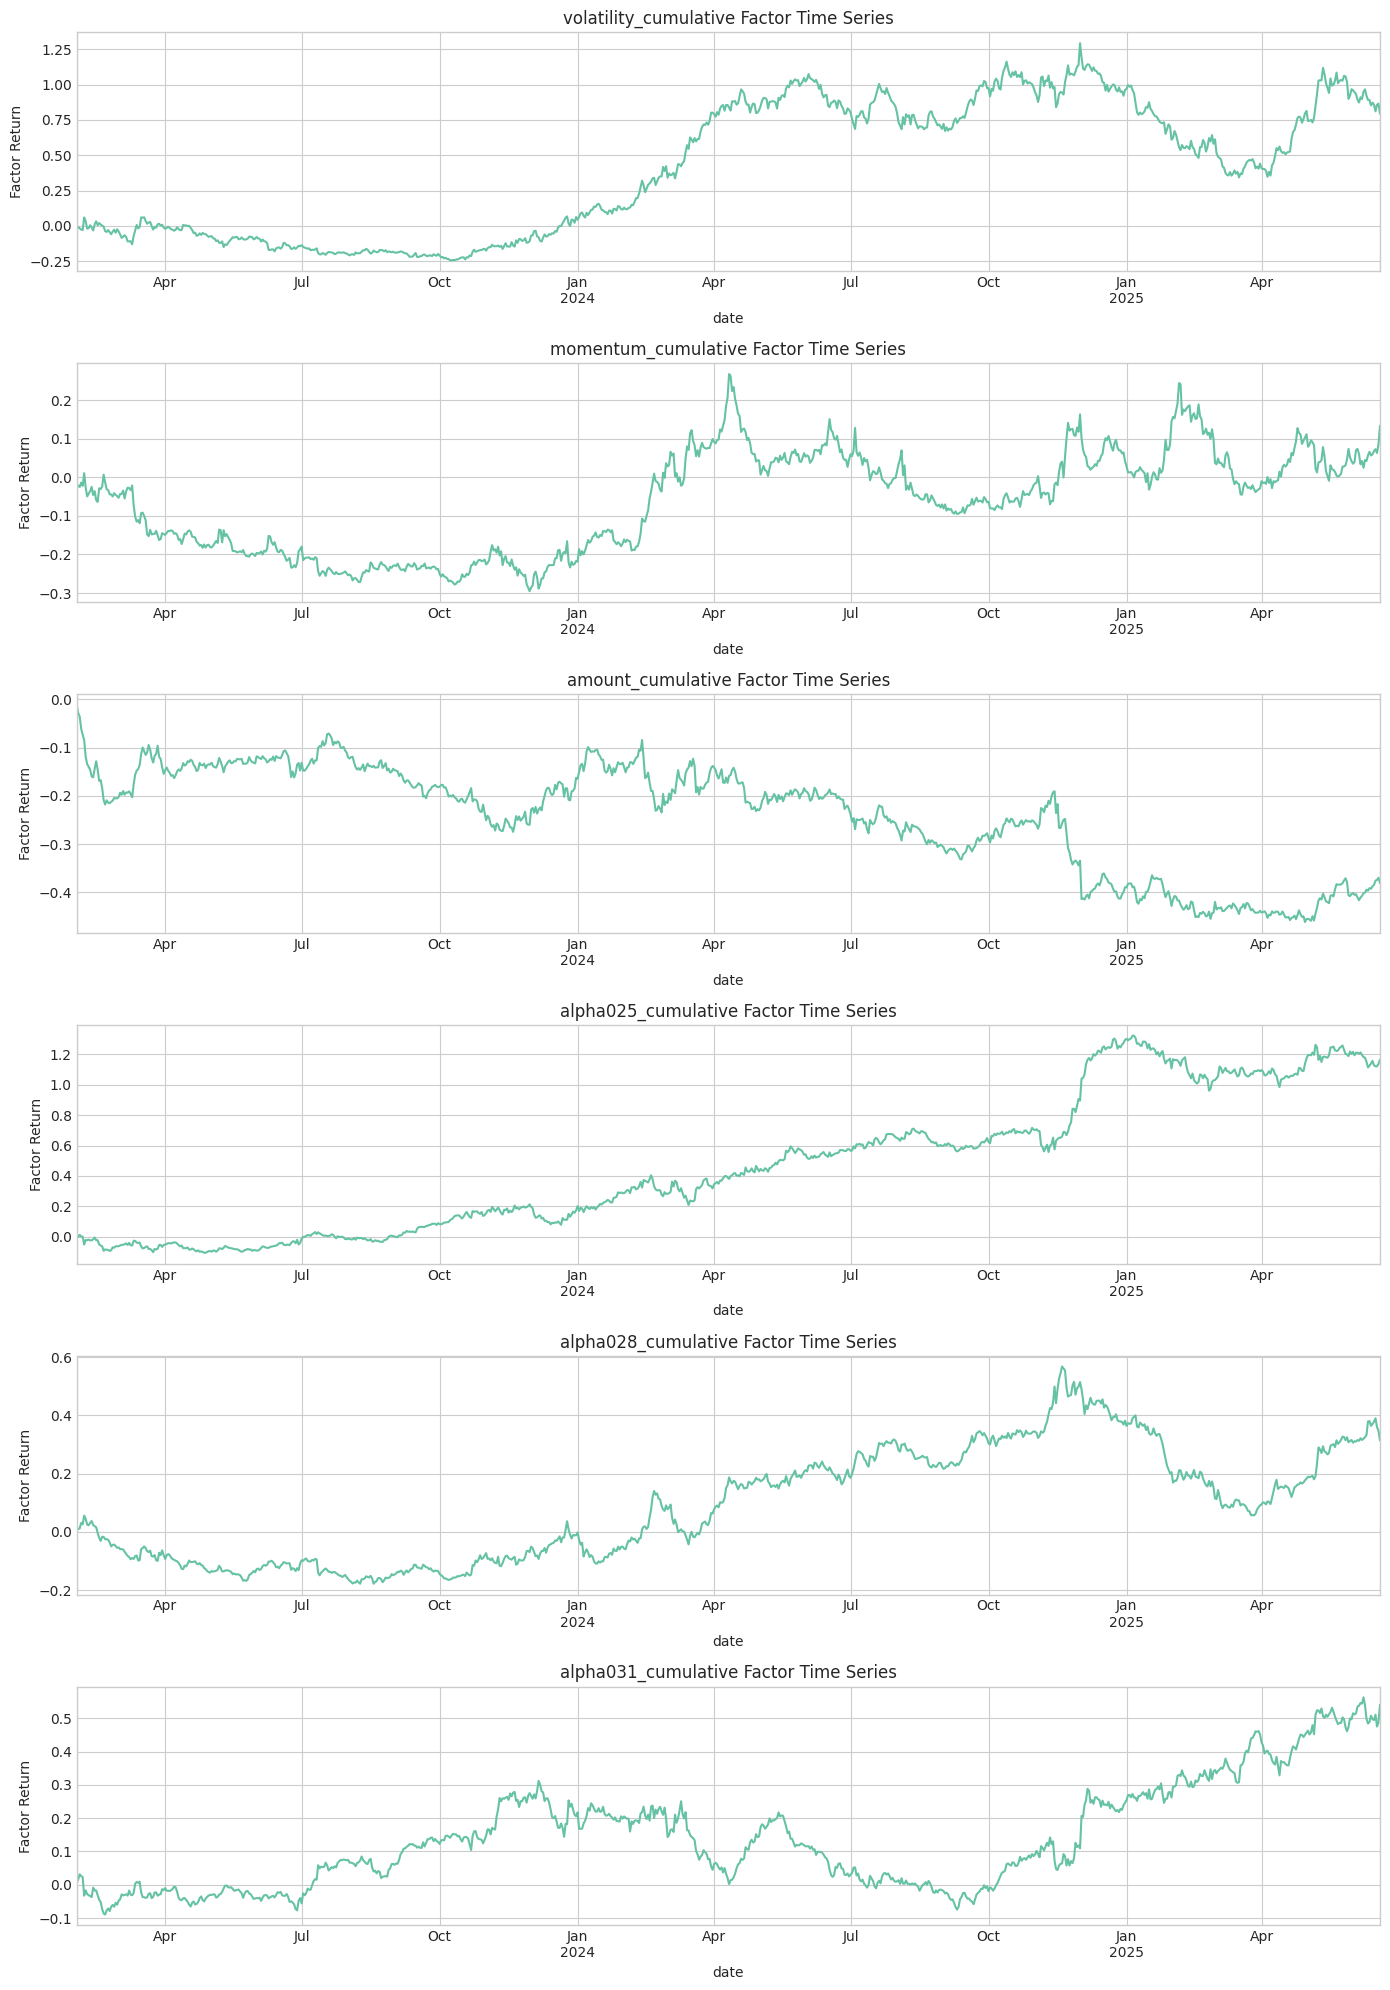

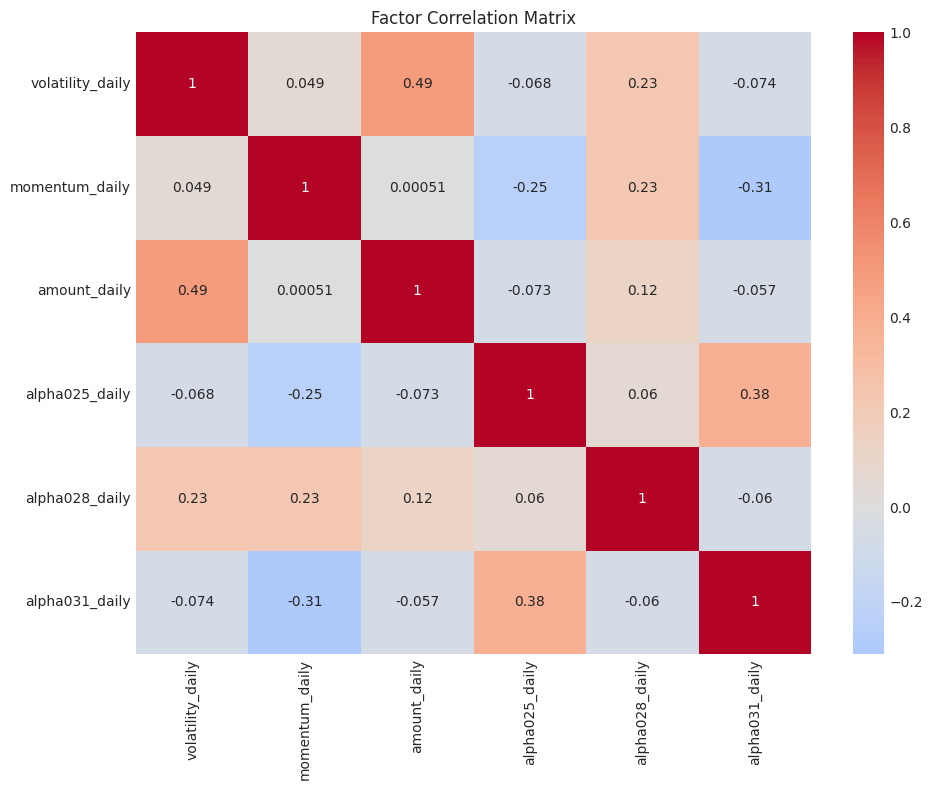

In [164]:
# 绘制因子时间序列
fig, axes = plt.subplots(len(factor_list), 1, figsize=(14, 20))
for i, factor in enumerate([i + '_cumulative' for i in factor_list]):
    factors[factor].plot(ax=axes[i], title=f'{factor} Factor Time Series')
    axes[i].set_ylabel('Factor Return')
plt.tight_layout()
plt.savefig('factor_time_series.png', dpi=300)

# # 绘制因子相关性热力图
plt.figure(figsize=(10, 8))
sns.heatmap(factors[[i + '_daily' for i in factor_list]].corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Factor Correlation Matrix')
plt.tight_layout()
plt.savefig('factor_correlation.png', dpi=300)

Building factor portfolios...


Processing alpha031 portfolios: 100%|██████████| 870/870 [00:02<00:00, 366.52it/s]


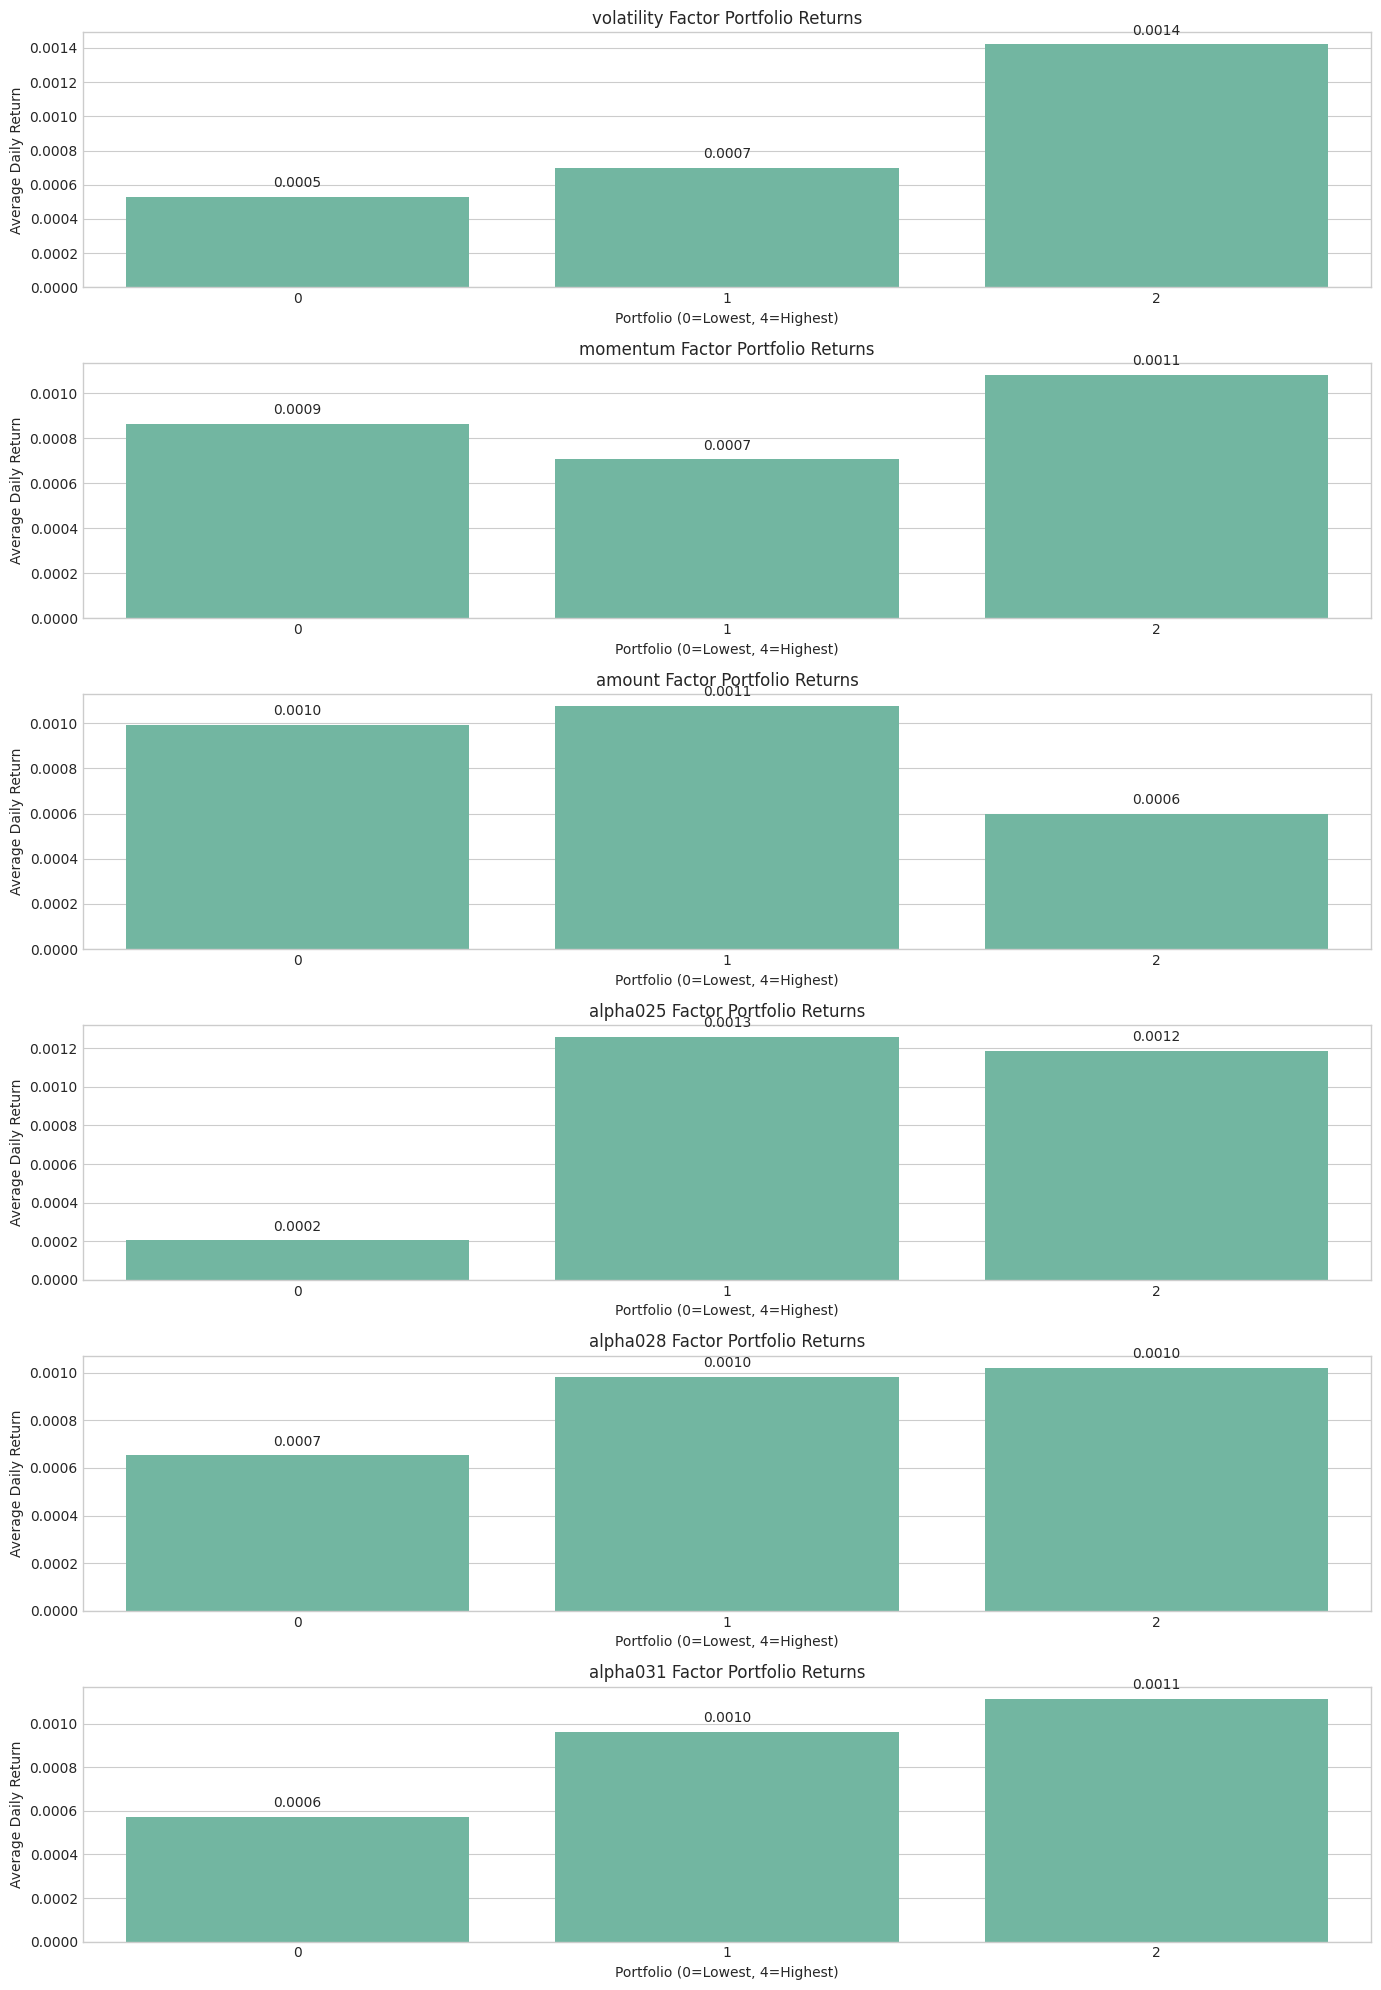

In [165]:
print("Building factor portfolios...")
n_portfolios = group_period

data = data.copy()
data = data[data['date'].isin(factors.index)]

portfolio_dfs = []

for factor in factor_list:
    portfolio_returns = []
    
    for date, group in tqdm(data.groupby('date'), desc=f"Processing {factor} portfolios"):
        if len(group) < n_portfolios * 3:  # 确保有足够样本
            continue
        # 按因子值分组
        group = group.sort_values(factor)
        group['portfolio'] = pd.qcut(group[factor], n_portfolios, labels=False)
        
        # 计算每个组合的等权重收益率
        port_ret = group.groupby('portfolio')['next_day_return'].mean().reset_index()
        port_ret['date'] = date
        portfolio_returns.append(port_ret)
    
    portfolio_returns = pd.concat(portfolio_returns)
    portfolio_returns['factor'] = factor
    portfolio_dfs.append(portfolio_returns)

portfolio_returns = pd.concat(portfolio_dfs)

# 计算投资组合表现统计
portfolio_stats = []
for factor in factor_list:
    for portfolio in range(n_portfolios):
        port_ret = portfolio_returns[
            (portfolio_returns['factor'] == factor) & 
            (portfolio_returns['portfolio'] == portfolio)]['next_day_return']
        
        stats = {
            'factor': factor,
            'portfolio': portfolio,
            'mean_return': port_ret.mean(),
            'std_dev': port_ret.std(),
            'sharpe': port_ret.mean() / port_ret.std() * np.sqrt(252),
            'skewness': port_ret.skew(),
            'kurtosis': port_ret.kurtosis(),
            'min': port_ret.min(),
            'max': port_ret.max()
        }
        portfolio_stats.append(stats)

portfolio_stats = pd.DataFrame(portfolio_stats)
fig, axes = plt.subplots(len(factor_list), 1, figsize=(14, 20))


portfolio_returns
for i, factor in enumerate(factor_list):
    factor_name = factor
    
    # 提取该因子的投资组合数据
    factor_data = portfolio_stats[portfolio_stats['factor'] == factor]
    
    # 绘制平均收益率
    ax = axes[i]
    sns.barplot(x='portfolio', y='mean_return', data=factor_data, ax=ax)
    ax.set_title(f'{factor_name} Factor Portfolio Returns')
    ax.set_xlabel('Portfolio (0=Lowest, 4=Highest)')
    ax.set_ylabel('Average Daily Return')
    
    # 添加数值标签
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), 
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('portfolio_performance.png', dpi=300)

In [166]:
def plot_cum_lamda(df,factor):
    df['cum_lamda'] = df['lamda'].cumsum()
    # 设置图形大小
    plt.figure(figsize=(16, 4))
    # 绘制lamda曲线
    plt.subplot(1, 1, 1)
    plt.plot(df['date'], df['cum_lamda'], 'b-', label='lamda')
    plt.title(f'{factor} Time Series of lamda')
    plt.ylabel(f'{factor}_lamda')
    plt.grid(True)
    plt.legend()
    # 自动调整子图间距
    plt.tight_layout()
    # 显示图形
    plt.show()

def plot_cum_all(df):
    df['cum_lamda'] = df['lamda'].cumsum()
    # 设置图形大小
    plt.figure(figsize=(12, 8))
    # 绘制lamda曲线
    plt.subplot(3, 1, 1)
    plt.plot(df['date'], df['cum_lamda'], 'b-', label='lamda')
    plt.title('Time Series of lamda, rsquared and t_lamda')
    plt.ylabel('lamda')
    plt.grid(True)
    plt.legend()
    # 绘制rsquared曲线
    plt.subplot(3, 1, 2)
    plt.plot(df['date'], df['rsquared'], 'r-', label='rsquared')
    plt.ylabel('rsquared')
    plt.grid(True)
    plt.legend()
    # 绘制t_lamda曲线
    plt.subplot(3, 1, 3)
    plt.plot(df['date'], df['t_lamda'], 'g-', label='t_lamda')
    plt.xlabel('Date')
    plt.ylabel('t_lamda')
    plt.grid(True)
    plt.legend()
    # 自动调整子图间距
    plt.tight_layout()
    # 显示图形
    plt.show()

Running Every T OLS regression...


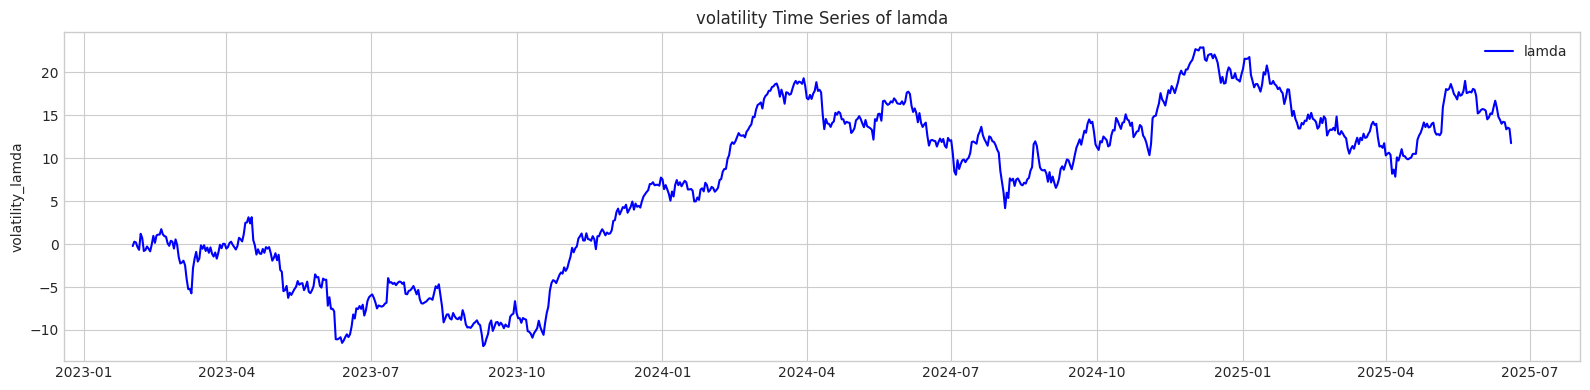

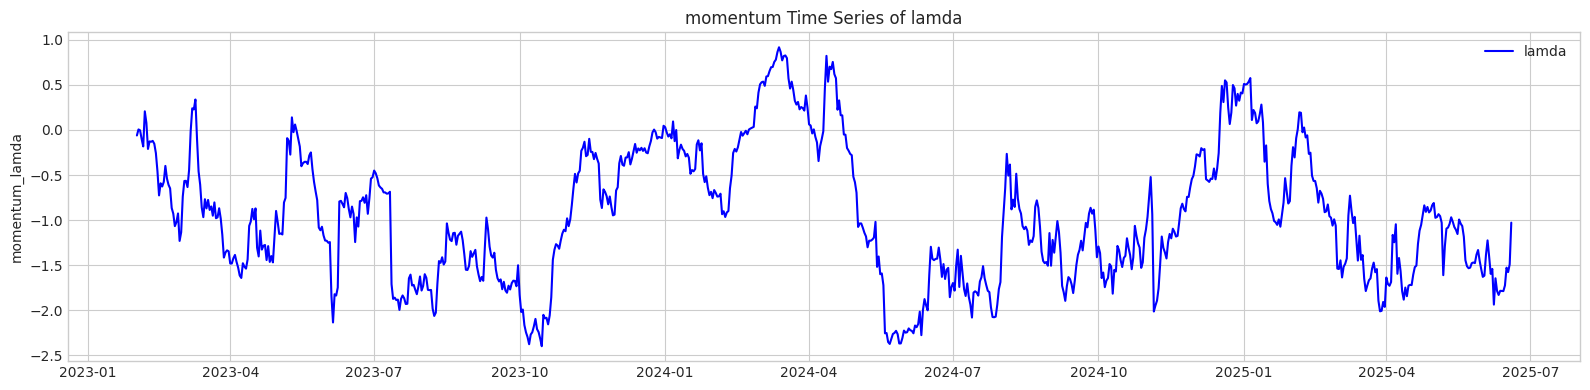

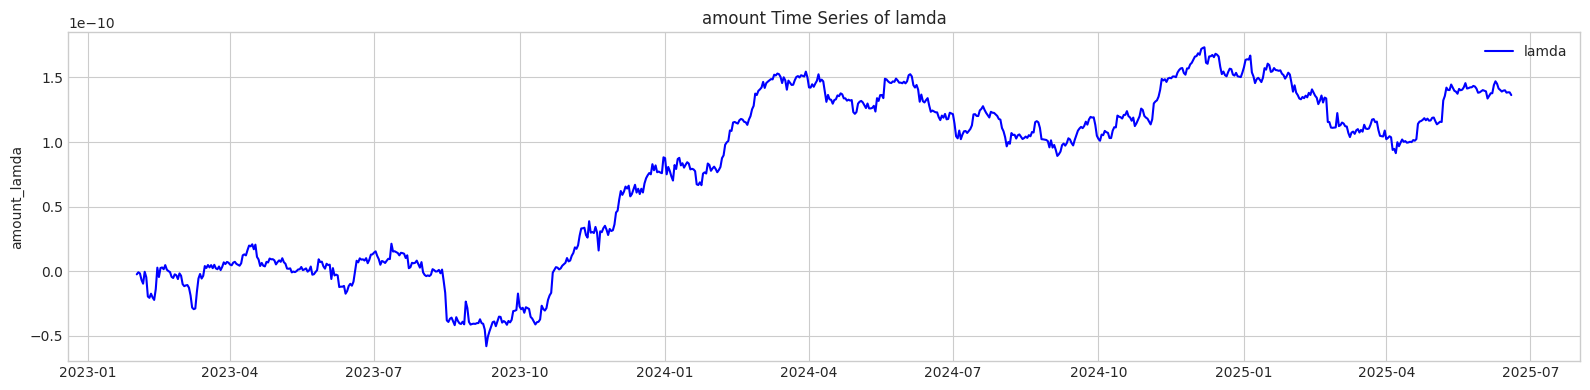

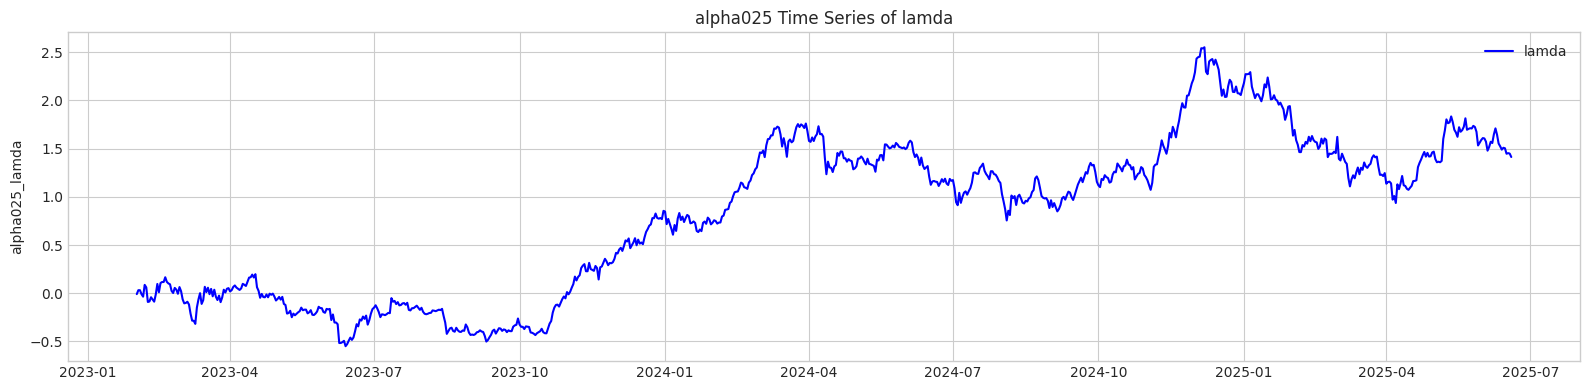

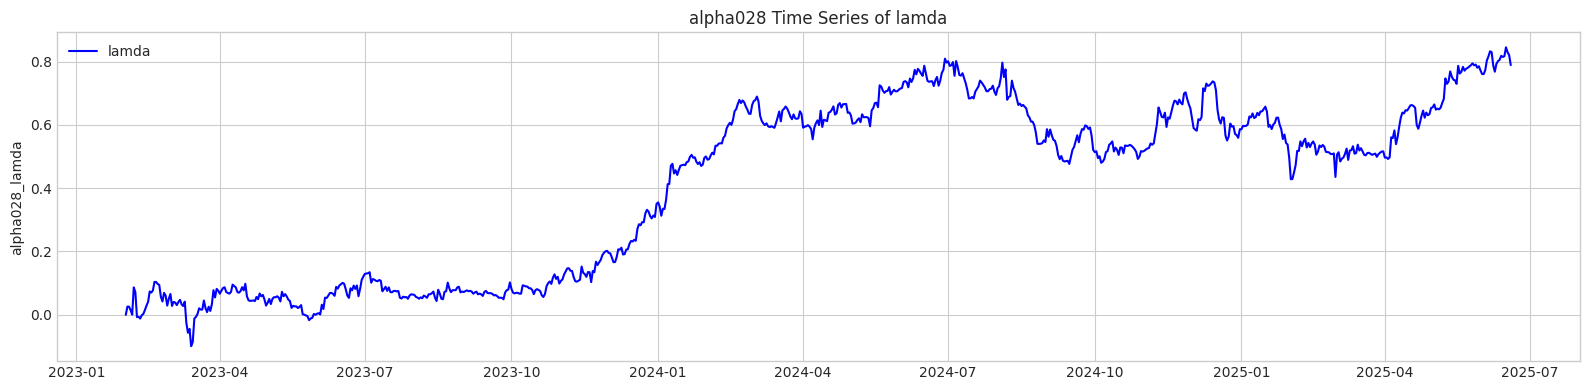

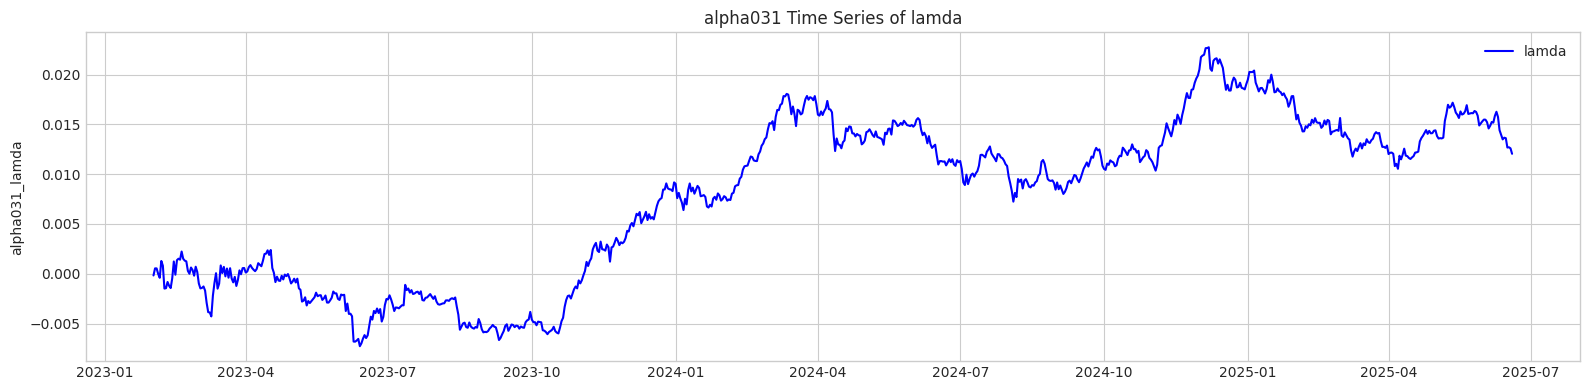

In [167]:
print("Running Every T OLS regression...")

# 准备数据
data = data.copy()
def cross_sectional_regression(df,factor):
    """对单个时间点的横截面数据运行线性回归"""
    X = df[factor]  # 自变量（因子值）
    y = df['next_day_return']  # 因变量（下一期收益）
    # X = sm.add_constant(X)  # 添加截距项
    model = sm.OLS(y, X).fit()
    return model.params[factor],model.rsquared,model.tvalues[factor]  # 返回因子收益系数


for single_factor in factor_list:
    factor_premium = data.groupby('date').apply(cross_sectional_regression,single_factor)
    
    # 转换为DataFrame
    factor_premium_df = pd.DataFrame(
        factor_premium.tolist(),
        index=factor_premium.index,
        columns=['lamda', 'rsquared', 't_lamda']
    )
    
    # 可选：重置索引将date变为列
    factor_premium_df = factor_premium_df.reset_index()
    plot_cum_lamda(factor_premium_df,single_factor)

Running Tumbling T Windows OLS regression...


Running rolling regression: 100%|██████████| 870/870 [00:02<00:00, 369.26it/s]


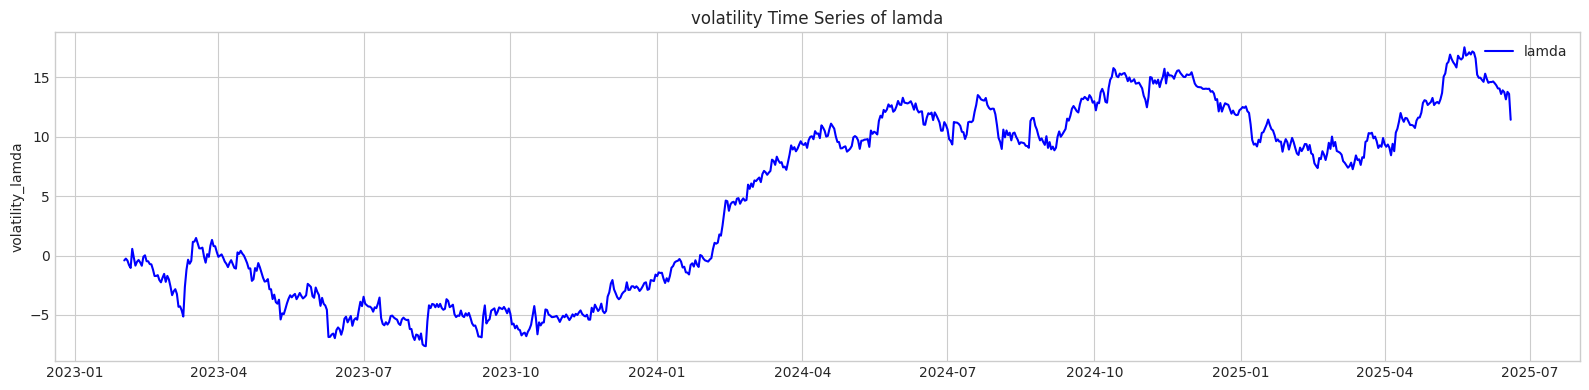

Running rolling regression: 100%|██████████| 870/870 [00:02<00:00, 369.05it/s]


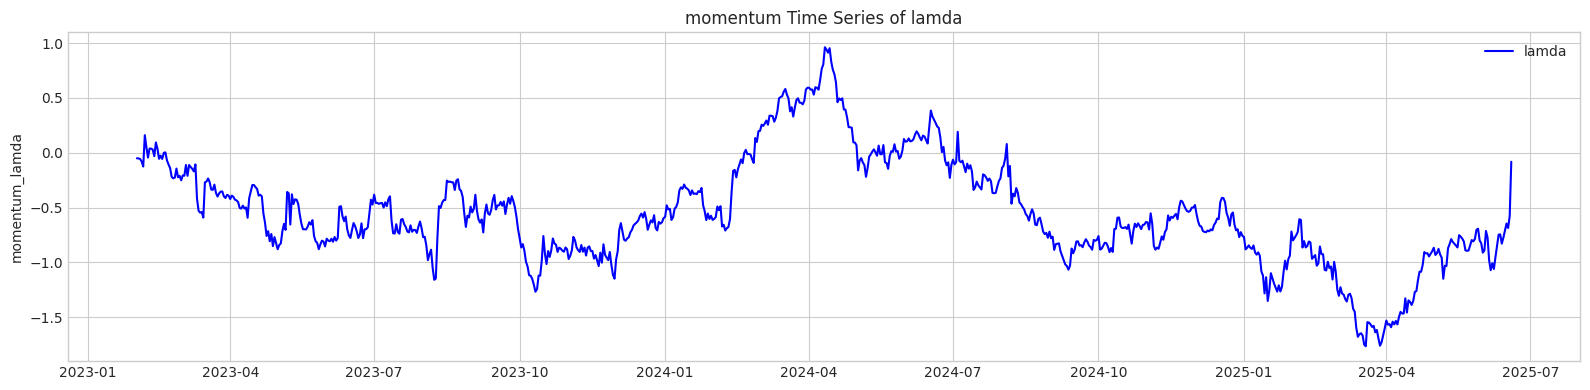

Running rolling regression: 100%|██████████| 870/870 [00:02<00:00, 369.10it/s]


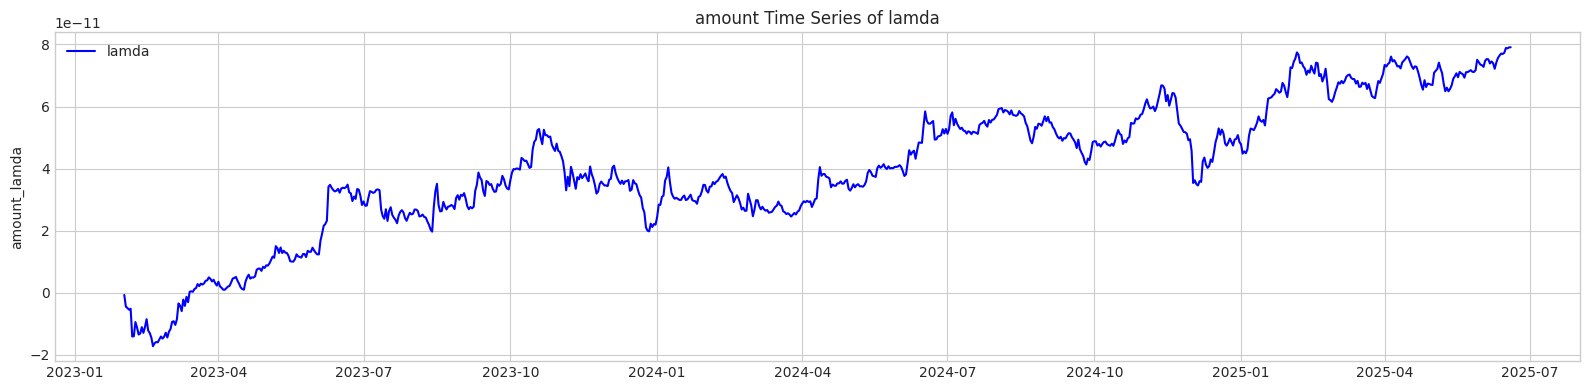

Running rolling regression: 100%|██████████| 870/870 [00:02<00:00, 373.21it/s]


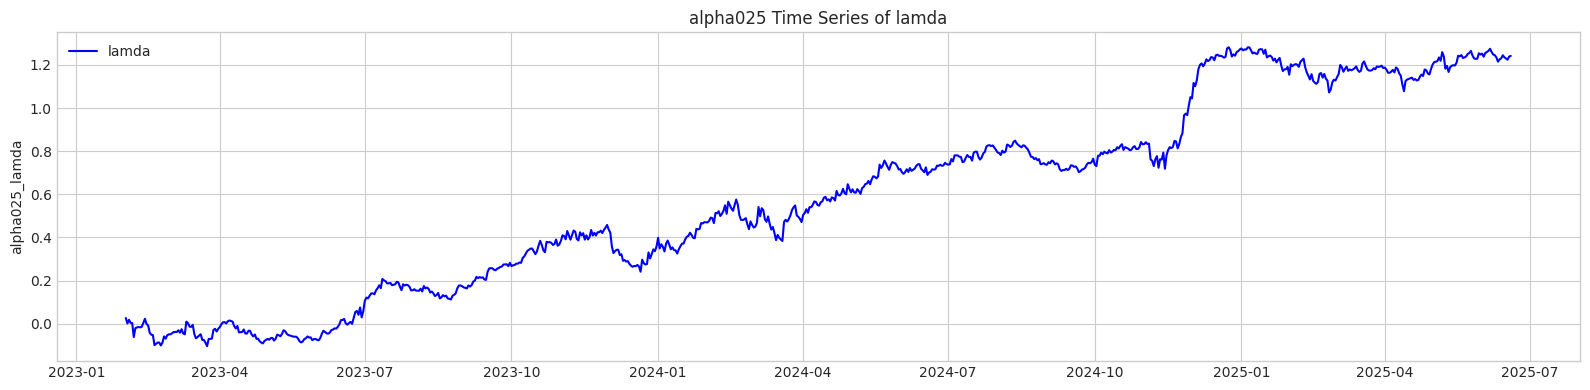

Running rolling regression: 100%|██████████| 870/870 [00:02<00:00, 368.63it/s]


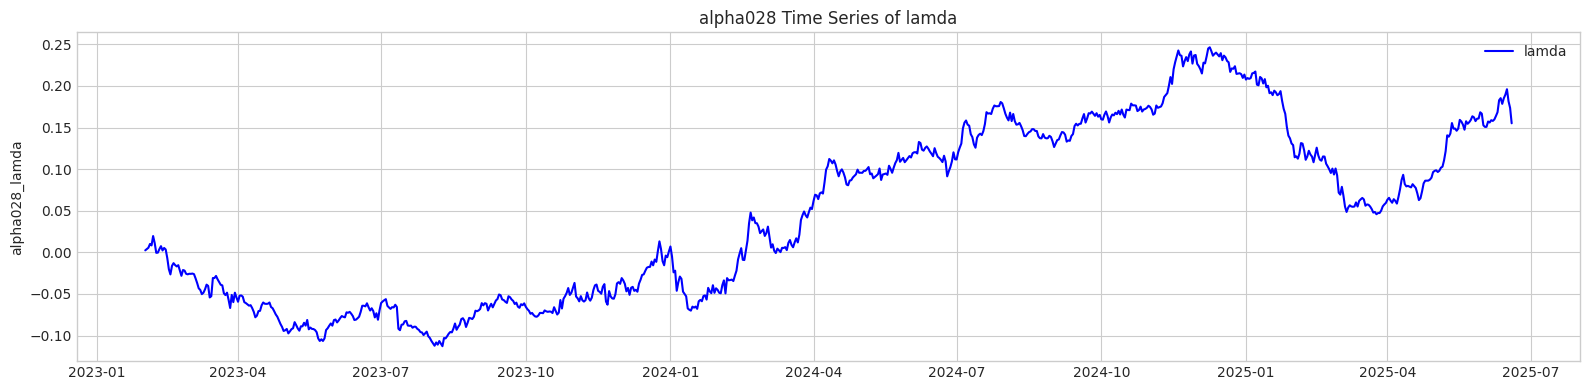

Running rolling regression: 100%|██████████| 870/870 [00:02<00:00, 374.22it/s]


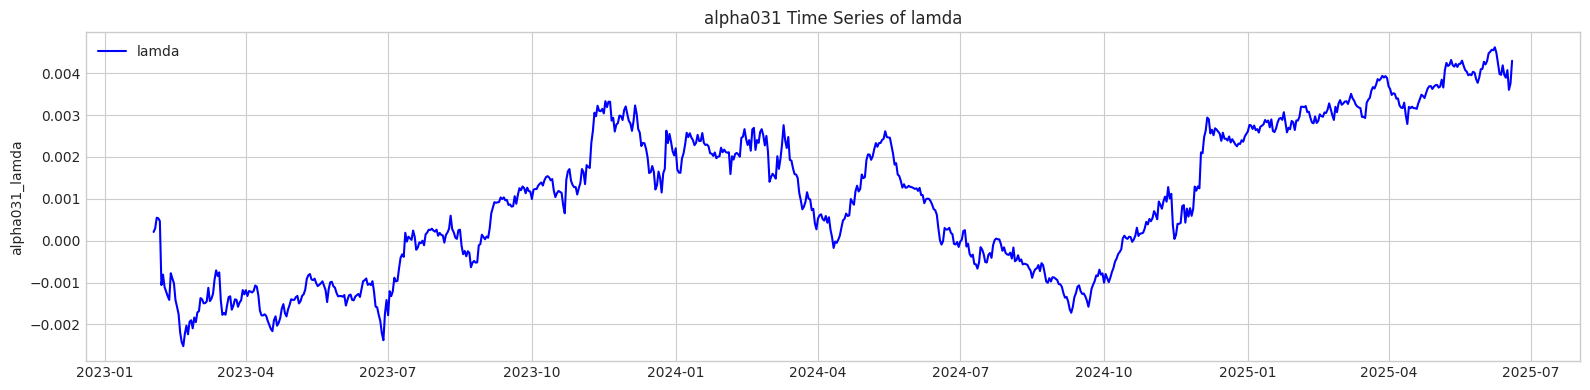

In [168]:
print("Running Tumbling T Windows OLS regression...")
def rolling_cross_sectional_regression(data, factor, window_size=30):
    """
    滚动横截面回归分析
    """
    # 确保数据按日期排序
    data = data.sort_values('date').copy()
    
    # 获取唯一日期列表
    unique_dates = data['date'].unique()
    
    # 准备存储结果
    results = []
    
    # 使用tqdm显示进度条
    for i in tqdm(range(len(unique_dates)), desc="Running rolling regression"):
        if i < window_size - 1:
            continue  # 跳过不足窗口大小的初期数据
            
        # 获取当前窗口的日期范围
        current_date = unique_dates[i]
        start_date = unique_dates[i - window_size + 1]
        
        # 提取窗口数据
        window_data = data[(data['date'] >= start_date) & (data['date'] <= current_date)]
            
        try:
            # 运行横截面回归
            X = window_data[factor]
            y = window_data['next_day_return']
            X = sm.add_constant(X)  # 如果需要截距项
            model = sm.OLS(y, X).fit()
            
            # 存储结果
            results.append((
                current_date,
                model.params[factor] if factor in model.params else model.params[0],
                model.rsquared,
                model.tvalues[factor] if factor in model.tvalues else model.tvalues[0]
            ))
        except:
            results.append((current_date, None, None, None))
    
    # 转换为DataFrame
    result_df = pd.DataFrame(results, columns=['date', 'lamda', 'rsquared', 't_lamda'])
    
    return result_df.dropna()  # 删除包含NaN的行


data = data.copy()
for single_factor in factor_list:
    factor_premium_df = rolling_cross_sectional_regression(data, single_factor, window_size=1)
    plot_cum_lamda(factor_premium_df,single_factor)